# Introduction train model

# Add root to sys.path

In [1]:
import os
import sys

# Add the root directory to the Python path
module_dir = os.path.abspath('../..')
if module_dir not in sys.path:
    sys.path.append(module_dir)
for x in sys.path:
    print(x)

/opt/anaconda3/envs/python312/lib/python312.zip
/opt/anaconda3/envs/python312/lib/python3.12
/opt/anaconda3/envs/python312/lib/python3.12/lib-dynload

/Users/hale/.local/lib/python3.12/site-packages
/opt/anaconda3/envs/python312/lib/python3.12/site-packages
/opt/anaconda3/envs/python312/lib/python3.12/site-packages/setuptools/_vendor
/Users/hale/PycharmProjects/MathAssertGPT


# Imports

In [2]:
from pathlib import Path

import torch

from notebooks.create_settings.Settings import Settings

from source.shared import Encoder
from source.create_model import create_model
from source.shared import load_model
from source.train_model import train_model
from source.evaluate_model import ModelEvaluator
from source.shared import SyntaxDeriverValidationReporter
from source.train_model import plot_correct
from source.shared import generate_predicted_dictum

# Settings

In [3]:
import panel as pn
pn.extension()
pn.config.sizing_mode="stretch_width"

settings = Settings()
settings.view()

WidgetBox(max_width=600, sizing_mode='stretch_width')
    [0] Column(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width')
    [1] Column(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width')
        [1] IntInput(name='Limit count', sizing_mode='stretch_width', value=40000)
    [2] Column(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width')
        [1] IntInput(name='n_embd', sizing_mode='stretch_width', value=1000)
        [2] IntInput(name='n_head', sizing_mode='stretch_width', value=10)
        [3] IntInput(name='block_size', sizing_mode='stretch_width', value=150)
        [4] FloatInput(name='dropout', sizing_mode='stretch_width', value=0.2)
        [5] IntInput(name='n_layer', sizing_mode='stretch_width', value=10)
    [3] Column(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width')
        [1] FloatInput(name='learning_rate', sizing_mode='stretch_width', value=0.0001)
    [4] Column(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width')
        [1] LiteralInput(name='mmx_file_path', sizing_mode='stretch_width', value='/Users/hale/PycharmProjec...)
        [2] LiteralInput(name='corpus01_file_path', sizing_mode='stretch_width', value='/Users/hale/PycharmProjec...)
        [3] LiteralInput(name='corpus_folder_path', sizing_mode='stretch_width', value='/Users/hale/PycharmProjec...)
        [4] LiteralInput(name='model_folder_path', sizing_mode='stretch_width', value='/Users/hale/PycharmProjec...)
    [5] Column(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width')

# Load model

In [4]:
# load model
def set_up_model() -> Path:
    model_folder_path = Path(settings.model_folder_path)
    model_name = 'model.pt'
    model_file_path = model_folder_path.joinpath(model_name).resolve()
    if model_file_path.exists():
        print(f"model_file already exists: {model_file_path}")
    else:
        create_model(settings=settings)
    return model_file_path

model_file_path = set_up_model()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.backends.mps.is_available():
    device = "mps"
print(f'device={device}')
encoder = Encoder.load_from_json(corpus_folder_path=settings.corpus_folder_path)
print(f'loading model and optimizer from checkpoint={model_file_path}')
model, optimizer = load_model(model_checkpoint_path=model_file_path, device=device, encoder=encoder)

settings.block_size = 150
Start create model and optimizer
create_model: model_file_path=/Users/hale/PycharmProjects/MathAssertGPT/notebooks/model/model.pt
create_encoder
vocab_size=160
create model: block_size=150 device=cpu
120.57216 M parameters
create a PyTorch optimizer
model created at path=/Users/hale/PycharmProjects/MathAssertGPT/notebooks/model/model.pt
Done
device=cpu
loading model and optimizer from checkpoint=/Users/hale/PycharmProjects/MathAssertGPT/notebooks/model/model.pt


# Train model

In [8]:
# train model
max_train_epochs = 10 * 10 * 1 * 1 * 1
train_model(model, optimizer, max_train_epochs=max_train_epochs, corpus_folder_path=settings.corpus_folder_path, model_folder_path=settings.model_folder_path)

vocab_size=160
corpus_file_path=/Users/hale/PycharmProjects/MathAssertGPT/notebooks/corpus/corpus.txt
corpus_statement_count=43457
#encoded_train_statements=43457
=== train and evalate model ===
epoch=10; step=100; n_head=10; n_layer=10
train_batch_size=10
max_train_epochs=100 eval_interval=10
block_size=150 n_head=10 n_layer=10 learning_rate=0.0001 device=cpu
#train_dataset=43457
       0. train loss 1.0723
      10. train loss 0.7319
      20. train loss 0.5501
      30. train loss 1.0792
      40. train loss 0.8109
      50. train loss 0.6957
      60. train loss 0.6537
      70. train loss 0.6143
      80. train loss 0.5750
      90. train loss 0.7634
      99. train loss 0.8682
elapsed_time=10.41 minutes
epoch=110; step=1100
saving model: epoch=110 model_checkpoint_path=/Users/hale/PycharmProjects/MathAssertGPT/notebooks/model/model.pt


# Evaluate model

In [9]:
%%time
def print_context(context):
    parts = context.split('\n')
    if len(parts) >= 2:
        print(f'prompt: {parts[0]}')
        print(f'predicted_statement: {parts[1]}')

def evaluate_model(model, max_examples: int, max_print_error: int, max_print_ok: int):
    model_evaluator = ModelEvaluator(corpus_folder_path=settings.corpus_folder_path, model=model)
    model_evaluator.evaluate_model(max_examples=max_examples)
    syntax_deriver_db= model_evaluator.syntax_deriver.syntax_deriver_db
    validation_reporter = SyntaxDeriverValidationReporter(syntax_deriver_db=syntax_deriver_db, block_size=settings.block_size)
    validation_reporter.print_validation_report(max_print_error=max_print_error, max_print_ok=max_print_ok, print_context=print_context)

    # print(f'\n=== Show all tables ===')
    # syntax_deriver = model_evaluator.syntax_deriver
    # syntax_deriver.syntax_deriver_db.show_math_statements_table()
    # syntax_deriver.syntax_deriver_db.show_rule_errors_table()
    # print(f'\n=== Show main_view ===')
    # syntax_deriver.syntax_deriver_db.create_main_view()
    # syntax_deriver.syntax_deriver_db.print_main_view()

max_examples = 10 * 1 * 1 * 1
max_print_error = 3
max_print_ok = 0
if max_examples > 0:
    evaluate_model(model=model, max_examples=max_examples, max_print_error=max_print_error, max_print_ok=max_print_ok)

vocab_size=160
epoch=110; step=1100; n_head=10; n_layer=10
=== start evaluate_model ===
max_val_examples=10
10. error_count=10

=== print_validation_report ===

===== Example 1 error:1 =====
prompt: |- 
predicted_statement: |- ( A e. A ) <|over|>
SyntaxDeriverWffRuleError
derivation_correct_count=2
cv: x mark_index=0 token_count=3 current_token_count=3
	full_statement: ( A e. A )
	statement_part: ( A
	statement_rest: e. A )
	statement_peek: 
	expected: x got: e.
co: ( A F B ) mark_index=0 token_count=3 current_token_count=3
	full_statement: ( A e. A )
	statement_part: ( A
	statement_rest: e. A )
	statement_peek: 
	expected: ( got: e.
===== Example 2 error:2 =====
prompt: |- 
predicted_statement: |- ( ( { E! y ) ) -> ( ph -> y <-> F _V ) -> ( ps ) ) ` E. dom ( ( { B /\ ( A ( C <-> A E. A /\ A e. X = X ) /\ ~P A. B <-> ( x e. A. x / =/= = R <-> D ) ) <|over|>
SyntaxDeriverWffRuleError
derivation_correct_count=2
wi: ( ph -> ps ) mark_index=0 token_count=60 current_token_count=60
	full_sta

# Plot

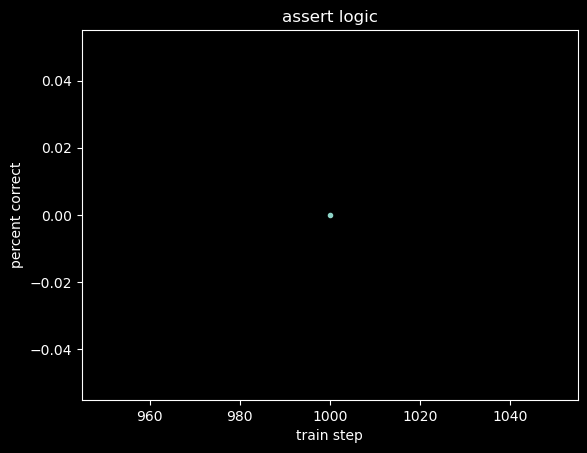

In [10]:
plot_correct(model_folder_path=settings.model_folder_path, bucket_count=50, xlabel='train step', ylabel='percent correct', title='assert logic')

# New statement percentage

In [11]:
%%time
def get_set_of_train_examples():
    corpus_file_path = Path(settings.corpus_folder_path).joinpath('corpus.txt').resolve()
    with open(corpus_file_path, 'r') as file:
        train_examples = file.read().split('\n')
    set_of_train_examples = set(train_examples) # used to see if the inference is in the train examples
    return set_of_train_examples

def print_new_statement_percentage(max_statement_count: int):
    _ = model.eval() # put model in inference mode (not training mode)
    new_count = 0
    prompt = '|- '
    terminal_token = '<|over|>'
    set_of_train_examples = get_set_of_train_examples() # used to see if the inference is in the train examples
    for _ in range(max_statement_count):
        predicted_dictum = generate_predicted_dictum(prompt=prompt, terminal_token=terminal_token, model=model)
        if predicted_dictum not in set_of_train_examples:
            new_count += 1
    print(f'new_statement_percentage={100 * new_count / max_statement_count: .0f}%')

print_new_statement_percentage(max_statement_count=10 * 1)

new_statement_percentage= 100%
CPU times: user 4min 33s, sys: 2.89 s, total: 4min 36s
Wall time: 18.6 s
